In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

In [2]:
# Cell 2: Load dataset
# (Thay đường dẫn file CSV nếu cần)
df = pd.read_csv("../Dataset/QK-video_subset_5M.csv")

print("📊 Kích thước dữ liệu:", df.shape)
df.head()

📊 Kích thước dữ liệu: (5000000, 10)


,user_id,item_id,click,follow,like,share,video_category,watching_times,gender,age
0,1,1,1,0,0,0,1,1,1,4
1,1,2,1,0,0,0,1,1,1,4
2,1,3,1,0,0,0,0,1,1,4
3,1,4,0,0,0,0,1,0,1,4
4,2,5,1,0,0,0,1,1,1,4


In [3]:
# Cell 3: Chuẩn bị features và target
target = "click"
X = df.drop(columns=[target])
y = df[target]

# Xác định categorical features
categorical_feats = ['user_id', 'item_id', 'video_category', 'gender', 'age']

# Chuyển sang dạng category để LightGBM nhận diện
for col in categorical_feats:
    X[col] = X[col].astype("category")

print("✅ Đã convert các cột categorical")


✅ Đã convert các cột categorical


In [4]:
# Cell 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🔹 Train size:", X_train.shape)
print("🔹 Test size:", X_test.shape)


🔹 Train size: (4000000, 9)
🔹 Test size: (1000000, 9)


In [5]:
# Cell 5: Tạo dataset cho LightGBM
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_feats)
test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_feats)

In [11]:
from lightgbm import early_stopping, log_evaluation
params = {
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc'],
    'boosting': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'device_type': 'cpu'
}
callbacks = [
    early_stopping(stopping_rounds=50),
    log_evaluation(period=50)
]

model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=500,
    callbacks=callbacks
)


Training until validation scores don't improve for 50 rounds
[50]	training's binary_logloss: 0.482486	training's auc: 0.82544	valid_1's binary_logloss: 0.483824	valid_1's auc: 0.823624
[100]	training's binary_logloss: 0.469607	training's auc: 0.833578	valid_1's binary_logloss: 0.471934	valid_1's auc: 0.830805
[150]	training's binary_logloss: 0.463968	training's auc: 0.838652	valid_1's binary_logloss: 0.467126	valid_1's auc: 0.835129
[200]	training's binary_logloss: 0.460463	training's auc: 0.841754	valid_1's binary_logloss: 0.464355	valid_1's auc: 0.837604
[250]	training's binary_logloss: 0.457861	training's auc: 0.84391	valid_1's binary_logloss: 0.462456	valid_1's auc: 0.839112
[300]	training's binary_logloss: 0.455862	training's auc: 0.845504	valid_1's binary_logloss: 0.461089	valid_1's auc: 0.84019
[350]	training's binary_logloss: 0.454279	training's auc: 0.846659	valid_1's binary_logloss: 0.460077	valid_1's auc: 0.840919
[400]	training's binary_logloss: 0.452961	training's auc: 0.8

In [12]:
# Cell 7: Predict & Evaluate
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"✅ Accuracy: {acc:.4f}")
print(f"✅ Precision: {prec:.4f}")
print(f"✅ Recall: {rec:.4f}")
print(f"✅ F1 Score: {f1:.4f}")


✅ Accuracy: 0.7799
✅ Precision: 0.8050
✅ Recall: 0.5774
✅ F1 Score: 0.6724


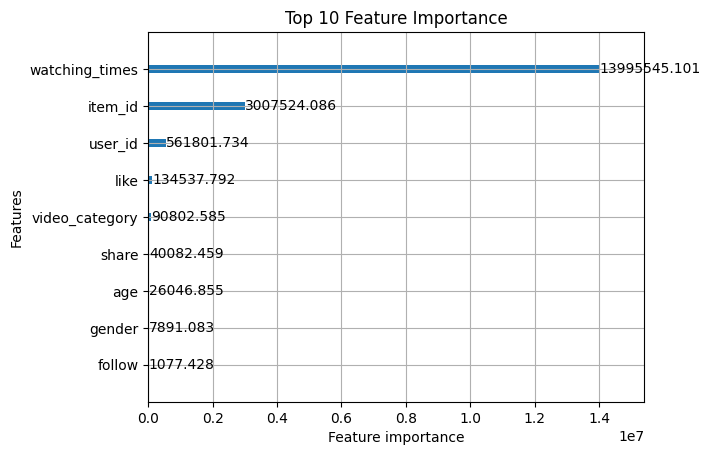

In [13]:
# Cell 8: Feature importance
import matplotlib.pyplot as plt

lgb.plot_importance(model, max_num_features=10, importance_type='gain')
plt.title("Top 10 Feature Importance")
plt.show()